# Positional Information — How Transformers Know Order

In [14]:
import numpy as np

In [15]:
def positional_encoding(seq_len, d_model):
    position = np.arange(seq_len)[:, np.newaxis]

    dimension = np.arange(d_model)[np.newaxis, :]

    angle_rates = 1 / np.power(
        10000,
        (2 * dimension // 2) / d_model
    )

    angles = position * angle_rates

    encoding = np.zeros((seq_len, d_model))

    encoding[:, 0::2] = np.sin(angles[:, 0::2])
    encoding[:, 1::2] = np.cos(angles[:, 1::2])

    return encoding

In [16]:
seq_len = 10
d_model = 8

pe = positional_encoding(seq_len, d_model)

print(pe)
print("Shape: ", pe.shape)

[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 8.41470985e-01  9.50415280e-01  9.98334166e-02  9.99500042e-01
   9.99983333e-03  9.99995000e-01  9.99999833e-04  9.99999950e-01]
 [ 9.09297427e-01  8.06578410e-01  1.98669331e-01  9.98000667e-01
   1.99986667e-02  9.99980000e-01  1.99999867e-03  9.99999800e-01]
 [ 1.41120008e-01  5.82753611e-01  2.95520207e-01  9.95503374e-01
   2.99955002e-02  9.99955000e-01  2.99999550e-03  9.99999550e-01]
 [-7.56802495e-01  3.01137463e-01  3.89418342e-01  9.92010661e-01
   3.99893342e-02  9.99920001e-01  3.99998933e-03  9.99999200e-01]
 [-9.58924275e-01 -1.03423189e-02  4.79425539e-01  9.87526020e-01
   4.99791693e-02  9.99875003e-01  4.99997917e-03  9.99998750e-01]
 [-2.79415498e-01 -3.20796458e-01  5.64642473e-01  9.82053935e-01
   5.99640065e-02  9.99820005e-01  5.99996400e-03  9.99998200e-01]
 [ 6.56986599e-01 -5.99437393e-01  6.44217687e-01  9.75599878e-01
   

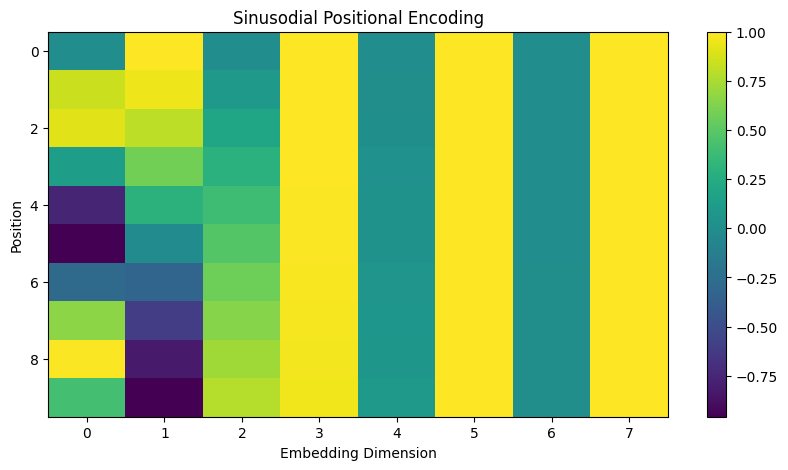

In [17]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(10, 5))

plt.imshow(pe, aspect="auto")

plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.title("Sinusodial Positional Encoding")

plt.colorbar()

plt.show()

In [18]:
embedding_dim = 8
vocab_size = 20

embedding_matrix = np.random.randn(
    vocab_size,
    embedding_dim
)

In [19]:
token_ids = np.array([3, 7, 2 ,10])

token_embedding = embedding_matrix[token_ids]

print("Token Embedding Shape: ",
      token_embedding.shape)


Token Embedding Shape:  (4, 8)


In [20]:
position_embedding = positional_encoding(
    seq_len=4,
    d_model=8
)

In [21]:
transformer_input = (
    token_embedding + 
    position_embedding
)

print("Transformer Input Shape: ",
      transformer_input.shape)

Transformer Input Shape:  (4, 8)


## Practical Task

Shape:  (20, 16)


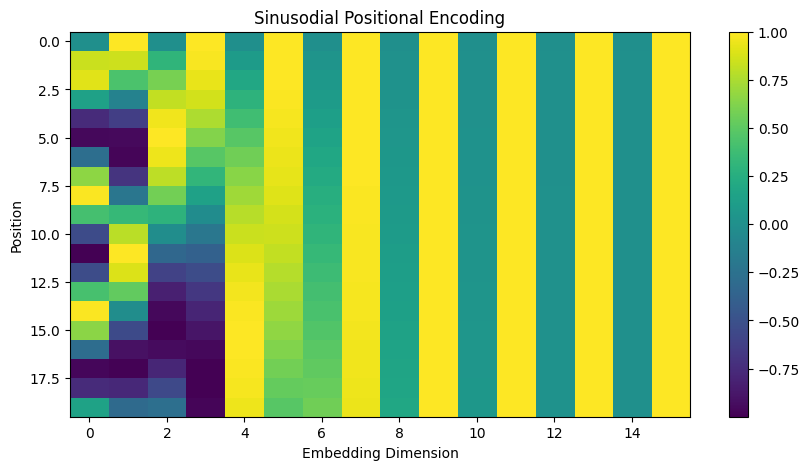

In [22]:
pe = positional_encoding(
    seq_len=20,
    d_model=16
)

print("Shape: ", pe.shape)

plt.figure(figsize=(10, 5))

plt.imshow(pe, aspect="auto")

plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.title("Sinusodial Positional Encoding")

plt.colorbar()

plt.show()

In [23]:
embedding_matrix = np.random.randn(100, 16)

token_ids = np.array([
    5, 12, 27, 9, 41
])

In [26]:
token_embedding = embedding_matrix[token_ids]

position_embedding = positional_encoding(
    seq_len=5,
    d_model=16
)

In [27]:
transformer_input = (
    token_embedding + 
    position_embedding
)

In [29]:
print("Token embeddings:", token_embedding.shape)
print("Position encoding:", position_embedding.shape)
print("Transformer input:", transformer_input.shape)

Token embeddings: (5, 16)
Position encoding: (5, 16)
Transformer input: (5, 16)
